# Training-dynamics diagnostics (cells 32–37, 40–41 of the original notebook)

$\rho$ vs $\eta/s$ over training, saturating-hypothesis activity,
dense-cadence logged diagnostics, and the chord-tight vs chord-direction
implicit-schedule comparison.


In [1]:
%load_ext autoreload
%autoreload 2

import json

import numpy as np
import torch
import matplotlib.pyplot as plt

from lora_playground.snapshot_analysis import (
    # snapshot registry + cached loader
    SNAP_ROOT, SNAP_ROOTS, STEPS, STEPS_BY_ROOT,
    RUNS, RUN_A, RUN_B, RUN_C, RUN_D,
    load_snapshot, clear_snapshot_cache,
    # adam-moment / spectrum helpers
    Mtilde, normalized_sigmas, normalized_sigmas_x, stable_rank,
    EPS, BETA1, BETA2,
    # whitening
    spd_half_inv, whitened_NS_input, DELTA_ABS,
    # SSC / polar shape
    _prerescale_unit_op, _polar_uvt, _ssc_svd, _ssc_misr_batched,
    # diagnostic NS iteration (trajectory-returning)
    newton_schulz_polar, polar_express,
)

DEV = SSC_DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEV}')
print(f'active RUNS: {RUNS}')
print(f'default STEPS: {STEPS}')

device: cuda
active RUNS: [('3e-2', 64, 5, 'chord-tight'), ('1e-1', 64, 5, 'chord-tight'), ('1e-3', 256, 10, 'chord-tight-clean'), ('1e-1', 256, 10, 'chord-tight-clean')]
default STEPS: [0, 50, 200, 500, 1000, 2000, 4000]


## How active is the bilinear term? ρ vs η/s over training

Tight-chord radius (§8 Prop 3, eq 6): $\rho = \tfrac{1}{2}(-s + \sqrt{s^2 + 4\eta})$ with $s = \sigma_{\max}(A) + \sigma_{\max}(B)$.

Two regimes:
- **Linear** ($s^2 \gg \eta$): $\rho \approx \eta/s$, second-order $\Delta B \Delta A$ term negligible.
- **Square-root** ($s^2 \ll \eta$): $\rho \approx \sqrt{\eta} - s/2$, bilinear term dominates.

Diagnostic: $\rho / (\eta/s)$ — close to 1 means deep linear regime. Plot per-pair distribution across snapshot steps.

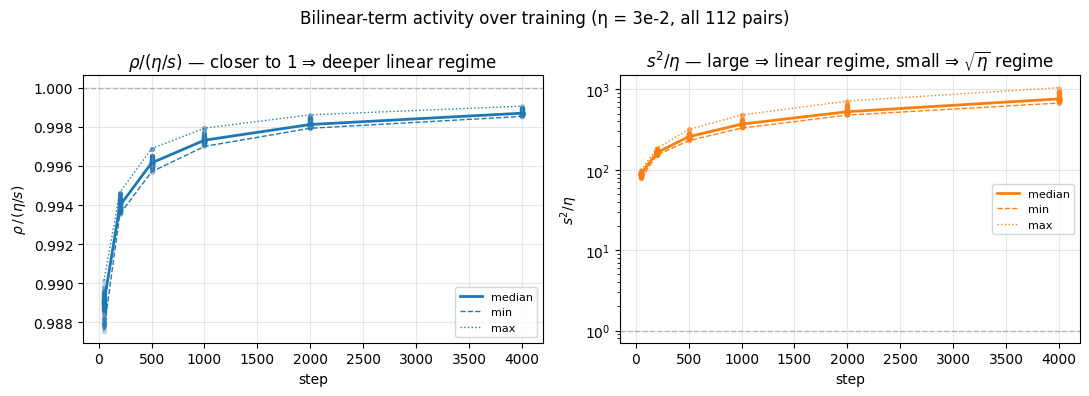

step | median ρ/(η/s) |   min   |   max   | median s²/η
   50 |    0.98899    | 0.98758 | 0.99014 |      88.8
  200 |    0.99396    | 0.99353 | 0.99464 |     163.7
  500 |    0.99615    | 0.99570 | 0.99688 |     257.9
 1000 |    0.99731    | 0.99700 | 0.99793 |     370.3
 2000 |    0.99812    | 0.99792 | 0.99861 |     528.9
 4000 |    0.99869    | 0.99853 | 0.99905 |     763.4


In [2]:
def collect_rho_over_time(eta=3e-2):
    rows = []
    for step in STEPS:
        if step == 0:
            continue  # B initialized to zero — s ≈ 0, undefined regime
        snap = load_snapshot(step)
        DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
        for pi, p in snap['pair_state'].items():
            A = p['A'].float().to(DEV); B = p['B'].float().to(DEV)
            sA_max = torch.linalg.svdvals(A)[0].item()
            sB_max = torch.linalg.svdvals(B)[0].item()
            s = sA_max + sB_max
            rho = 0.5 * (-s + (s*s + 4*eta)**0.5)
            rows.append(dict(step=step, pi=pi, s=s, rho=rho,
                             rho_over_rholin=rho * s / eta,
                             s2_over_eta=(s*s)/eta))
    return rows

rows = collect_rho_over_time(eta=3e-2)
steps_arr = sorted({r['step'] for r in rows})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for step in steps_arr:
    vals_ratio = [r['rho_over_rholin'] for r in rows if r['step'] == step]
    vals_s2eta = [r['s2_over_eta']     for r in rows if r['step'] == step]
    axes[0].scatter([step]*len(vals_ratio), vals_ratio, alpha=0.25, s=8, color='C0')
    axes[1].scatter([step]*len(vals_s2eta), vals_s2eta, alpha=0.25, s=8, color='C1')

for ax_i, key, color in [(0, 'rho_over_rholin', 'C0'), (1, 's2_over_eta', 'C1')]:
    med, mn, mx = [], [], []
    for step in steps_arr:
        vs = np.array([r[key] for r in rows if r['step'] == step])
        med.append(np.median(vs)); mn.append(vs.min()); mx.append(vs.max())
    axes[ax_i].plot(steps_arr, med, color=color, lw=2, label='median')
    axes[ax_i].plot(steps_arr, mn,  color=color, lw=1, ls='--', label='min')
    axes[ax_i].plot(steps_arr, mx,  color=color, lw=1, ls=':',  label='max')

axes[0].axhline(1.0, color='gray', ls='--', alpha=0.5, lw=1)
axes[0].set_ylabel(r'$\rho \,/\, (\eta / s)$')
axes[0].set_xlabel('step')
axes[0].set_title(r'$\rho / (\eta/s)$ — closer to 1 ⇒ deeper linear regime')
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

axes[1].set_yscale('log')
axes[1].axhline(1.0, color='gray', ls='--', alpha=0.5, lw=1)
axes[1].set_ylabel(r'$s^2 / \eta$')
axes[1].set_xlabel('step')
axes[1].set_title(r'$s^2 / \eta$ — large ⇒ linear regime, small ⇒ $\sqrt{\eta}$ regime')
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)

fig.suptitle(f'Bilinear-term activity over training (η = 3e-2, all 112 pairs)')
fig.tight_layout()
plt.show()

print('step | median ρ/(η/s) |   min   |   max   | median s²/η')
for step in steps_arr:
    vs = [r['rho_over_rholin'] for r in rows if r['step'] == step]
    s2 = [r['s2_over_eta']     for r in rows if r['step'] == step]
    print(f'{step:5d} |    {np.median(vs):.5f}    | {min(vs):.5f} | {max(vs):.5f} |   {np.median(s2):7.1f}')


## Saturating-hypothesis (H) activity over training (Algorithm 1 vs Algorithm 2)

(H) (§7 eq H): $\tau_A \le \eta\,\sigma_{\min}(c_A^{(n)})$, equivalently every singular value of $\eta\,c_A^{(n)}$ is at least $\tau_A$. When (H) holds, clip = polar on the whitened input and Algorithm 2 is exact (§9). When (H) fails, polar lifts small singular values that clip would have left alone.

At BJ iterate $n=1$, $\tilde u_A = u_A$ (the snapshot already has $u_A$), so $c_A^{(1)} = S_B^{-1/2}\,u_A$ is fully recoverable from the snapshot.

Diagnostics per pair per step:
- `min_ratio` = $\sigma_{\min}(\eta\,c_A^{(1)}) / \tau_A$ — (H) holds iff this is ≥ 1.
- `frac_below` = fraction of singular values of $\eta\,c_A^{(1)}$ that fall below $\tau_A$.
- `clip_polar_relF` = $\|\Delta A^{\text{clip}} - \Delta A^{\text{polar}}\|_F / \|\Delta A^{\text{polar}}\|_F$ at iterate 1 — direct measure of how much the saturating substitution costs the update.

A-side only (B-side is symmetric).

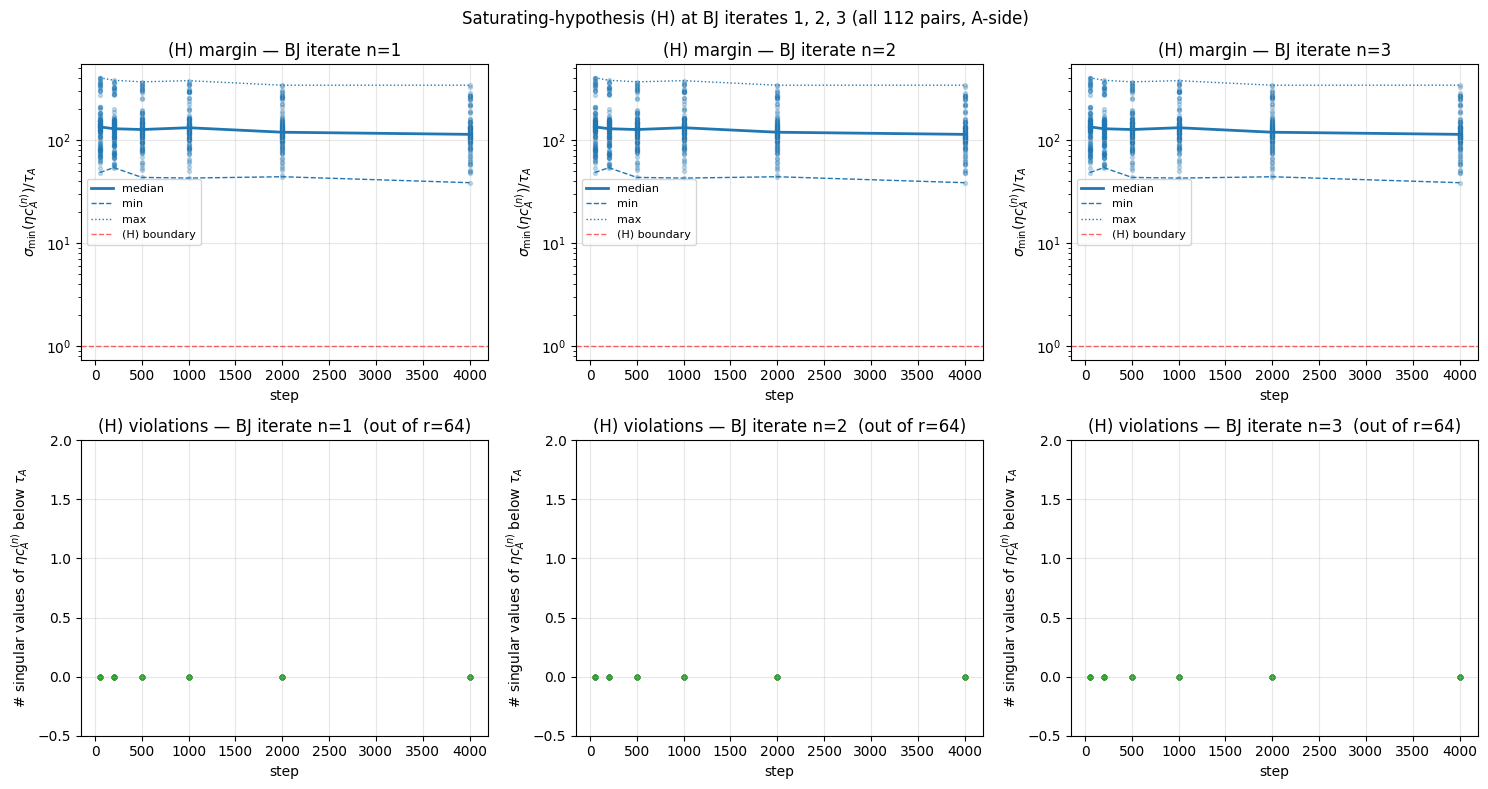

step | iter | med margin | min margin | max margin | median n_below | max n_below
   50 |    1 |     134.00 |      48.33 |     400.92 |              0 |           0
   50 |    2 |     133.97 |      48.29 |     400.88 |              0 |           0
   50 |    3 |     133.97 |      48.29 |     400.88 |              0 |           0
  200 |    1 |     128.57 |      53.94 |     379.32 |              0 |           0
  200 |    2 |     128.54 |      53.92 |     379.28 |              0 |           0
  200 |    3 |     128.54 |      53.92 |     379.28 |              0 |           0
  500 |    1 |     126.28 |      43.39 |     365.98 |              0 |           0
  500 |    2 |     126.25 |      43.38 |     365.95 |              0 |           0
  500 |    3 |     126.25 |      43.38 |     365.95 |              0 |           0
 1000 |    1 |     131.44 |      42.71 |     375.71 |              0 |           0
 1000 |    2 |     131.40 |      42.69 |     375.68 |              0 |           0
 1000

In [3]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'

def saturating_diag(step, eta=3e-2, delta_abs=1e-6, n_iters=3, ns_iters=5):
    """(H) check at BJ iterates 1..n_iters.  Runs the inner loop, computes
    min ratio sigma_i(eta*c_A^{(n)}) / tau_A at each iterate."""
    snap = load_snapshot(step)
    rows = []
    for pi, p in snap['pair_state'].items():
        A = p['A'].float().to(DEV); B = p['B'].float().to(DEV)
        u_A = p['u_A'].float().to(DEV); u_B = p['u_B'].float().to(DEV)
        r = A.shape[0]
        I_r = torch.eye(r, dtype=A.dtype, device=DEV)
        S_B = B.T @ B
        eB = torch.linalg.eigvalsh(S_B).clamp_min(0)
        delta_B = delta_abs
        e2B, UB = torch.linalg.eigh(S_B + delta_B * I_r)
        W_B = UB @ torch.diag(e2B.clamp_min(1e-30).rsqrt()) @ UB.T
        sB_max = eB.max().sqrt().item(); sB_min = eB.min().sqrt().item()
        S_A = A @ A.T
        eA = torch.linalg.eigvalsh(S_A).clamp_min(0)
        delta_A = delta_abs
        e2A, UA = torch.linalg.eigh(S_A + delta_A * I_r)
        W_A = UA @ torch.diag(e2A.clamp_min(1e-30).rsqrt()) @ UA.T
        sA_max = eA.max().sqrt().item(); sA_min = eA.min().sqrt().item()
        s = sA_max + sB_max
        rho = eta / s   # linear form
        tau_A = rho * (sB_min**2 + delta_B)**0.5
        tau_B = rho * (sA_min**2 + delta_A)**0.5

        dA = torch.zeros_like(A); dB = torch.zeros_like(B)
        margins_A = []; margins_B = []; n_below_A_list = []
        for n in range(n_iters):
            u_A_tilde = u_A + (1.0/eta) * (B.T @ dB @ A)
            u_B_tilde = u_B + (1.0/eta) * (B @ dA @ A.T)
            c_A = W_B @ u_A_tilde
            c_B = u_B_tilde @ W_A
            # All r singular values of eta*c_A via Gram
            sig_eta_cA = (eta*eta * torch.linalg.eigvalsh(c_A @ c_A.T).clamp_min(0)).sqrt()
            sig_eta_cB = (eta*eta * torch.linalg.eigvalsh(c_B.T @ c_B).clamp_min(0)).sqrt()
            margins_A.append((sig_eta_cA.min() / tau_A).item())
            margins_B.append((sig_eta_cB.min() / tau_B).item())
            n_below_A_list.append((sig_eta_cA < tau_A).sum().item())
            # Update for next iter
            D_A = W_B @ newton_schulz_polar(c_A, ns_iters)
            D_B = newton_schulz_polar(c_B, ns_iters) @ W_A
            D_A_op = torch.linalg.eigvalsh(D_A @ D_A.T).clamp_min(0).max().sqrt().item()
            D_B_op = torch.linalg.eigvalsh(D_B.T @ D_B).clamp_min(0).max().sqrt().item()
            dA = -rho * D_A / D_A_op
            dB = -rho * D_B / D_B_op

        # Iter-1 only: clip-vs-polar Frob distance (for legacy)
        c_A_1 = W_B @ u_A
        Uc, Sc, Vct = torch.linalg.svd(-eta * c_A_1, full_matrices=False)
        clip_inner = Uc @ torch.diag(Sc.clamp_max(tau_A)) @ Vct
        dA_clip = W_B @ clip_inner
        Up, Sp, Vpt = torch.linalg.svd(c_A_1, full_matrices=False)
        D_A_1 = W_B @ (Up @ Vpt)
        D_A_op = torch.linalg.eigvalsh(D_A_1 @ D_A_1.T).clamp_min(0).max().sqrt().item()
        dA_polar = -rho * D_A_1 / D_A_op
        rel_F = (dA_clip - dA_polar).norm().item() / dA_polar.norm().item()
        rows.append(dict(step=step, pi=pi,
                         margin_A_iter1=margins_A[0], margin_A_iter2=margins_A[1] if n_iters>1 else None,
                         margin_A_iter3=margins_A[2] if n_iters>2 else None,
                         margin_B_iter1=margins_B[0], margin_B_iter2=margins_B[1] if n_iters>1 else None,
                         margin_B_iter3=margins_B[2] if n_iters>2 else None,
                         n_below_A_iter1=n_below_A_list[0],
                         n_below_A_iter2=n_below_A_list[1] if n_iters>1 else None,
                         n_below_A_iter3=n_below_A_list[2] if n_iters>2 else None,
                         clip_polar_relF=rel_F))
    return rows

H_rows = []
for step in STEPS:
    if step == 0: continue
    H_rows.extend(saturating_diag(step, n_iters=3))

steps_arr = sorted({r['step'] for r in H_rows})

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top row: per-iterate (H) margin (min ratio) across pairs
for col, iter_n in enumerate([1, 2, 3]):
    key = f'margin_A_iter{iter_n}'
    for step in steps_arr:
        mr = [r[key] for r in H_rows if r['step'] == step]
        axes[0, col].scatter([step]*len(mr), mr, alpha=0.25, s=8, color='C0')
    med = []; mn = []; mx = []
    for step in steps_arr:
        vs = np.array([r[key] for r in H_rows if r['step'] == step])
        med.append(np.median(vs)); mn.append(vs.min()); mx.append(vs.max())
    axes[0, col].plot(steps_arr, med, color='C0', lw=2, label='median')
    axes[0, col].plot(steps_arr, mn,  color='C0', lw=1, ls='--', label='min')
    axes[0, col].plot(steps_arr, mx,  color='C0', lw=1, ls=':',  label='max')
    axes[0, col].axhline(1.0, color='red', ls='--', alpha=0.6, lw=1, label='(H) boundary')
    axes[0, col].set_yscale('log')
    axes[0, col].set_ylabel(r'$\sigma_{\min}(\eta c_A^{(n)}) / \tau_A$')
    axes[0, col].set_xlabel('step')
    axes[0, col].set_title(f'(H) margin — BJ iterate n={iter_n}')
    axes[0, col].grid(True, alpha=0.3); axes[0, col].legend(fontsize=8)

# Bottom row: n_below count at each iterate (should be 0 always)
for col, iter_n in enumerate([1, 2, 3]):
    key = f'n_below_A_iter{iter_n}'
    for step in steps_arr:
        nb_ = [r[key] for r in H_rows if r['step'] == step]
        axes[1, col].scatter([step]*len(nb_), nb_, alpha=0.25, s=8, color='C2')
    axes[1, col].set_ylim(-0.5, max(2, max(r[key] for r in H_rows) + 1))
    axes[1, col].set_ylabel(r'# singular values of $\eta c_A^{(n)}$ below $\tau_A$')
    axes[1, col].set_xlabel('step')
    axes[1, col].set_title(f'(H) violations — BJ iterate n={iter_n}  (out of r={H_rows[0].get("n", 64) if H_rows else 64})')
    axes[1, col].grid(True, alpha=0.3)

fig.suptitle('Saturating-hypothesis (H) at BJ iterates 1, 2, 3 (all 112 pairs, A-side)')
fig.tight_layout()
plt.show()

print('step | iter | med margin | min margin | max margin | median n_below | max n_below')
for step in steps_arr:
    for n in [1,2,3]:
        mr = np.array([r[f'margin_A_iter{n}'] for r in H_rows if r['step'] == step])
        nb_ = np.array([r[f'n_below_A_iter{n}'] for r in H_rows if r['step'] == step])
        print(f'{step:5d} | {n:>4d} | {np.median(mr):>10.2f} | {mr.min():>10.2f} | {mr.max():>10.2f} | {int(np.median(nb_)):>14d} | {int(nb_.max()):>11d}')


### Dense-cadence trajectory from the logged `optim_step` diagnostics

Snapshots are at 7 steps. The training log records per-pair-aggregated $\sigma_{\max}(AA^\top), \sigma_{\max}(B^\top B)$ as min/median/max across pairs every 80 steps (50 datapoints over 4000 steps). Use those to plot $\rho/(\eta/s)$ at full cadence.

Caveat: the median curve uses $s_{\text{med}} = \sqrt{S_{A,\max}^{\text{med}}} + \sqrt{S_{B,\max}^{\text{med}}}$ — the median-of-A plus median-of-B, not the median across pairs of the pairwise sum. The min/max envelope is also a loose bound for the same reason. For a properly per-pair view, the snapshot-based cell above is exact; this cell is a denser overlay.

parsed 50 optim_step events


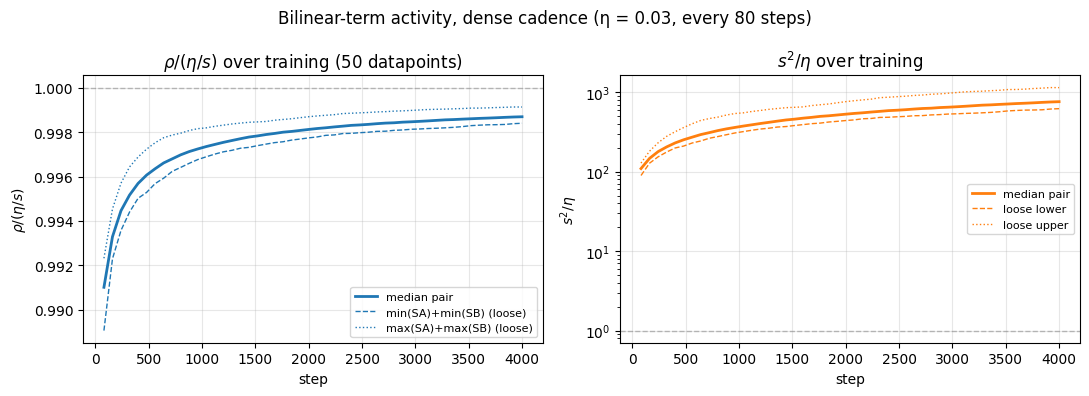


step | median ρ/(η/s) | loose min | loose max
   80 |    0.99102    |  0.98907  |  0.99232
  880 |    0.99712    |  0.99659  |  0.99807
 1680 |    0.99794    |  0.99752  |  0.99853
 2480 |    0.99832    |  0.99797  |  0.99886
 3280 |    0.99855    |  0.99819  |  0.99903
 4000 |    0.99869    |  0.99839  |  0.99913


In [4]:
LOG_PATH = '/mnt/home/nghosh/lora/logs/chord_tight_r64_k3_snapshot_blackwell/run_info/logs/log_0.out'

def parse_optim_steps(path):
    rows = []
    with open(path) as f:
        for line in f:
            try:
                d = json.loads(line)
            except json.JSONDecodeError:
                continue
            if d.get('event') == 'optim_step':
                rows.append(d)
    return rows

opt_rows = parse_optim_steps(LOG_PATH)
print(f'parsed {len(opt_rows)} optim_step events')

ETA = 3e-2
steps_arr = [r['step'] for r in opt_rows]

def rho_over_etas(sA2, sB2):
    s = np.sqrt(sA2) + np.sqrt(sB2)
    rho = 0.5 * (-s + np.sqrt(s*s + 4*ETA))
    return rho * s / ETA, (s*s) / ETA, s

ratio_med, s2_med, s_med = zip(*[rho_over_etas(r['SA_max_median'], r['SB_max_median']) for r in opt_rows])
ratio_min, s2_min, _     = zip(*[rho_over_etas(r['SA_max_min'],    r['SB_max_min'])    for r in opt_rows])
ratio_max, s2_max, _     = zip(*[rho_over_etas(r['SA_max_max'],    r['SB_max_max'])    for r in opt_rows])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(steps_arr, ratio_med, color='C0', lw=2, label='median pair')
axes[0].plot(steps_arr, ratio_min, color='C0', lw=1, ls='--', label='min(SA)+min(SB) (loose)')
axes[0].plot(steps_arr, ratio_max, color='C0', lw=1, ls=':', label='max(SA)+max(SB) (loose)')
axes[0].axhline(1.0, color='gray', ls='--', alpha=0.5, lw=1)
axes[0].set_xlabel('step'); axes[0].set_ylabel(r'$\rho / (\eta/s)$')
axes[0].set_title(r'$\rho / (\eta/s)$ over training (50 datapoints)')
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

axes[1].plot(steps_arr, s2_med, color='C1', lw=2, label='median pair')
axes[1].plot(steps_arr, s2_min, color='C1', lw=1, ls='--', label='loose lower')
axes[1].plot(steps_arr, s2_max, color='C1', lw=1, ls=':',  label='loose upper')
axes[1].set_yscale('log')
axes[1].axhline(1.0, color='gray', ls='--', alpha=0.5, lw=1)
axes[1].set_xlabel('step'); axes[1].set_ylabel(r'$s^2 / \eta$')
axes[1].set_title(r'$s^2/\eta$ over training')
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)

fig.suptitle(f'Bilinear-term activity, dense cadence (η = {ETA}, every 80 steps)')
fig.tight_layout()
plt.show()

print()
print(f'step | median ρ/(η/s) | loose min | loose max')
for i in [0, 10, 20, 30, 40, 49]:
    if i < len(steps_arr):
        print(f'{steps_arr[i]:5d} |    {ratio_med[i]:.5f}    |  {ratio_min[i]:.5f}  |  {ratio_max[i]:.5f}')


## Chord-tight vs chord-direction: implicit schedule comparison

Both algorithms use the IDENTICAL unit-op-norm direction P at each BJ iterate (cos(P_tight, P_dir) = 1 to float32 precision; ~0.99997 in float64 — see standalone probe). They differ only in the scalar magnitude:
- chord-tight:     $\rho_{\mathrm{tight}}(t) = \mathrm{lr} / s(t)$,   $s = \sigma_{\max}(A) + \sigma_{\max}(B)$
- chord-direction: $\lambda_{\mathrm{dir}}(t) = \mathrm{lr} / a_{\mathrm{dir}}(t)$,   $a_{\mathrm{dir}} = \sigma_{\max}(BP) + \sigma_{\max}(QA)$

Both runs log both schedules per step (one as the applied magnitude, the other as a diagnostic — see `lambda_dir`, `lambda_dir_gain` in `optim_step` events). So from a single run we get BOTH schedules on the same state trajectory.

**Two regimes shown side-by-side, each at the lr where that algorithm achieves its best val loss:**
- chord-tight optimal regime (lr=3e-2): chord-tight applies $\rho_{\mathrm{tight}}$, what chord-direction WOULD have done shown as overlay
- chord-direction optimal regime (lr=3e-3): chord-direction applies $\lambda_{\mathrm{dir}}$, what chord-tight WOULD have done shown as overlay

**Takeaway:** at low lr the two schedules nearly coincide (gain ≈ 1.2–1.4); at high lr they diverge sharply (gain grows from 3.8 to 8.9 over training). chord-direction is "too aggressive" at high lr because $a_{\mathrm{dir}}$ decays much slower than $s$ — its implicit schedule barely anneals. This is consistent with chord-direction diverging at lr=3e-2 in the leaderboard.

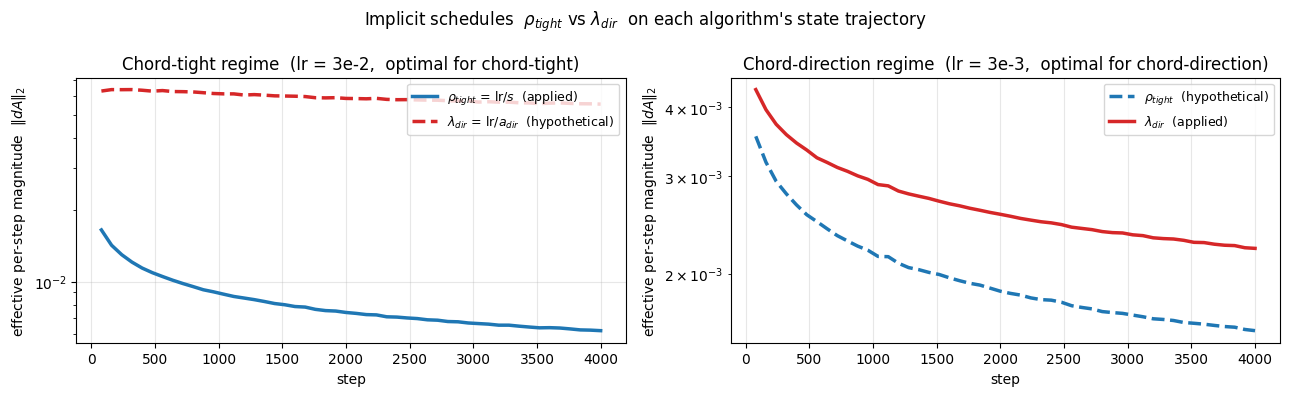


Gain = lambda_dir / rho_tight  (= s / a_dir) over training:
  at lr=3e-2 (chord-tight regime):     step 80 = 3.82, step 2000 = 7.89, step 4000 = 8.91
  at lr=3e-3 (chord-direction regime): step 80 = 1.21, step 2000 = 1.38, step 4000 = 1.41

At high lr the gap is huge — chord-direction would take 4-9x bigger steps than chord-tight at the same lr, which is too aggressive (chord-direction diverges at lr=3e-2).


In [5]:
import json as _json

def _parse_log(path):
    rows = []
    with open(path) as f:
        for line in f:
            try: d = _json.loads(line)
            except Exception: continue
            if d.get('event') == 'optim_step' and 'lambda_dir_median' in d:
                rows.append(d)
    return rows

def _extract(rows):
    steps = np.array([r['step'] for r in rows])
    lam = np.array([r['lambda_dir_median'] for r in rows])
    gain = np.array([r['lambda_dir_gain_median'] for r in rows])
    rho = lam / gain
    return dict(step=steps, lam=lam, gain=gain, rho=rho)

CT_LOG = '/mnt/home/nghosh/lora/logs/chord_tight_r64_k3_snapshot_blackwell/run_info/logs/log_0.out'
CD_LOG = '/mnt/home/nghosh/lora/logs/chord_direction_4k_r16r64_blackwell/run_info/logs/log_0.out'

E_ct = _extract(_parse_log(CT_LOG))   # chord-tight applied @ lr=3e-2
E_cd = _extract(_parse_log(CD_LOG))   # chord-direction applied @ lr=3e-3

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: lr = 3e-2 (chord-tight applied, chord-direction shown as diagnostic)
ax = axes[0]
ax.plot(E_ct['step'], E_ct['rho'], color='C0', lw=2.5, label=r'$\rho_{tight}$ = lr$/s$  (applied)')
ax.plot(E_ct['step'], E_ct['lam'], color='C3', lw=2.5, ls='--', label=r'$\lambda_{dir}$ = lr$/a_{dir}$  (hypothetical)')
ax.set_yscale('log')
ax.set_xlabel('step'); ax.set_ylabel(r'effective per-step magnitude  $\|dA\|_2$')
ax.set_title('Chord-tight regime  (lr = 3e-2,  optimal for chord-tight)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=9, loc='upper right')

# Right: lr = 3e-3 (chord-direction applied, chord-tight shown as diagnostic)
ax = axes[1]
ax.plot(E_cd['step'], E_cd['rho'], color='C0', lw=2.5, ls='--', label=r'$\rho_{tight}$  (hypothetical)')
ax.plot(E_cd['step'], E_cd['lam'], color='C3', lw=2.5, label=r'$\lambda_{dir}$  (applied)')
ax.set_yscale('log')
ax.set_xlabel('step'); ax.set_ylabel(r'effective per-step magnitude  $\|dA\|_2$')
ax.set_title('Chord-direction regime  (lr = 3e-3,  optimal for chord-direction)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=9, loc='upper right')

fig.suptitle(r"Implicit schedules  $\rho_{tight}$ vs $\lambda_{dir}$  on each algorithm's state trajectory")
fig.tight_layout()
plt.show()

print(f'\nGain = lambda_dir / rho_tight  (= s / a_dir) over training:')
print(f'  at lr=3e-2 (chord-tight regime):     step 80 = {E_ct["gain"][np.argmin(np.abs(E_ct["step"]-80))]:.2f}, step 2000 = {E_ct["gain"][np.argmin(np.abs(E_ct["step"]-2000))]:.2f}, step 4000 = {E_ct["gain"][-1]:.2f}')
print(f'  at lr=3e-3 (chord-direction regime): step 80 = {E_cd["gain"][np.argmin(np.abs(E_cd["step"]-80))]:.2f}, step 2000 = {E_cd["gain"][np.argmin(np.abs(E_cd["step"]-2000))]:.2f}, step 4000 = {E_cd["gain"][-1]:.2f}')
print(f'\nAt high lr the gap is huge — chord-direction would take 4-9x bigger steps than chord-tight at the same lr, which is too aggressive (chord-direction diverges at lr=3e-2).')
